# Trader Performance vs Market Sentiment Analysis

## Objective
To analyze how Bitcoin Fear & Greed sentiment influences trader behavior and performance on Hyperliquid, and derive actionable strategy insights.

This analysis evaluates performance differences across sentiment regimes, behavioral shifts, and trader segmentation to uncover actionable trading patterns.


In [388]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [389]:
# ============================================
# Load Datasets
# ============================================

# Load sentiment dataset (Bitcoin Fear & Greed Index)
sentiment = pd.read_csv("fear_greed_index.csv")

# Load trader activity dataset (Hyperliquid historical data)
trades = pd.read_csv("historical_data.csv")

# Display dataset dimensions
print(f"Sentiment dataset shape: {sentiment.shape}")
print(f"Trades dataset shape: {trades.shape}")

Sentiment dataset shape: (2644, 4)
Trades dataset shape: (211224, 16)


### Sentiment Dataset Preview
Below is a preview of the Bitcoin Fear & Greed Index dataset.

In [390]:
# Preview sentiment dataset
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Trader Dataset Preview
Below is a preview of the Hyperliquid historical trader dataset.

In [391]:
# Preview trader dataset
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Column Overview
Below are the column names for both datasets to understand structure before cleaning.

In [392]:
# Display column names for both datasets
print("Sentiment Columns:")
print(sentiment.columns.tolist())

print("\nTrades Columns:")
print(trades.columns.tolist())

Sentiment Columns:
['timestamp', 'value', 'classification', 'date']

Trades Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


### Missing Value Check
We examine both datasets for missing values before proceeding with merging and analysis.

In [393]:
# Check for missing values in both datasets
print("Missing Values — Sentiment Dataset:")
print(sentiment.isnull().sum())

print("\nMissing Values — Trades Dataset:")
print(trades.isnull().sum())

Missing Values — Sentiment Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values — Trades Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


### Duplicate Record Check
We verify whether duplicate rows exist in either dataset before performing analysis.

In [394]:
# Check for duplicate rows in both datasets
print("Duplicate Rows — Sentiment Dataset:", sentiment.duplicated().sum())
print("Duplicate Rows — Trades Dataset:", trades.duplicated().sum())

Duplicate Rows — Sentiment Dataset: 0
Duplicate Rows — Trades Dataset: 0


### Timestamp Standardization
Convert date and timestamp columns into a consistent daily format to enable accurate merging between sentiment and trade data.

In [395]:
# ============================================
# Convert Timestamps to Daily Level
# ============================================

# Convert sentiment date column to datetime and extract date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Convert trade timestamp (IST format) to datetime
trades['time'] = pd.to_datetime(
    trades['Timestamp IST'],
    format="%d-%m-%Y %H:%M"
)

# Extract date component for daily alignment
trades['date'] = trades['time'].dt.date

In [396]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,Extreme Greed


### Handling Missing Sentiment Labels

After merging trade data with sentiment data, a small number of rows did not have matching sentiment labels due to date mismatches.

These rows were removed to ensure clean and consistent alignment between trader behavior and market sentiment.

In [397]:
# ============================================
# Handling Missing Sentiment Labels
# ============================================

# Standardize sentiment column naming
df = df.rename(columns={'classification': 'sentiment'})

# Remove rows without sentiment classification
df = df.dropna(subset=['sentiment'])

## Performance Analysis by Sentiment

### Average PnL by Market Sentiment
We compare average trade profitability across sentiment regimes to evaluate performance differences.

In [398]:
# Calculate average PnL by sentiment regime
avg_pnl_by_sentiment = (
    df.groupby('sentiment')['Closed PnL']
    .mean()
    .sort_values()
)

avg_pnl_by_sentiment

,Closed PnL
sentiment,
Neutral,34.307718
Extreme Fear,34.537862
Greed,42.743559
Fear,54.290400
Extreme Greed,67.892861


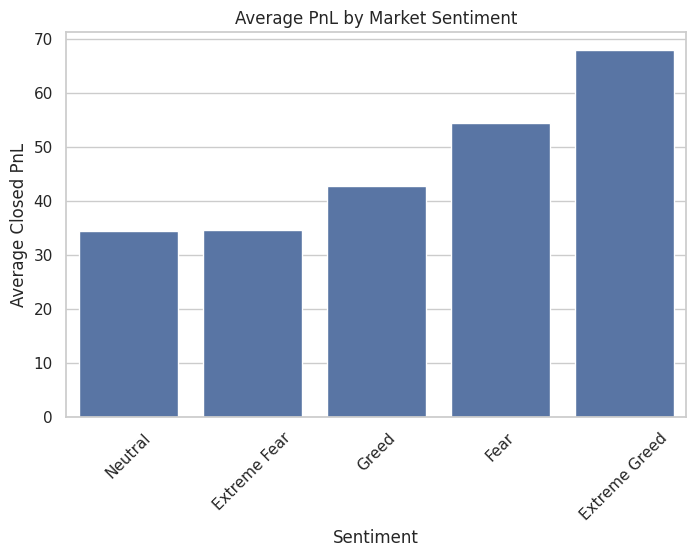

In [399]:
sns.barplot(
    x=avg_pnl_by_sentiment.index,
    y=avg_pnl_by_sentiment.values
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

### Win Rate by Sentiment

We calculate the proportion of profitable trades across different sentiment regimes to evaluate trade accuracy.

In [400]:
# ============================================
# Create Win Indicator
# ============================================

# Boolean indicator for profitable trades
df['win'] = df['Closed PnL'] > 0

# Calculate win rate by sentiment regime
win_rate_by_sentiment = (
    df.groupby('sentiment')['win']
    .mean()
    .sort_values()
)

win_rate_by_sentiment

,win
sentiment,
Extreme Fear,0.370607
Greed,0.384828
Neutral,0.396991
Fear,0.420768
Extreme Greed,0.464943


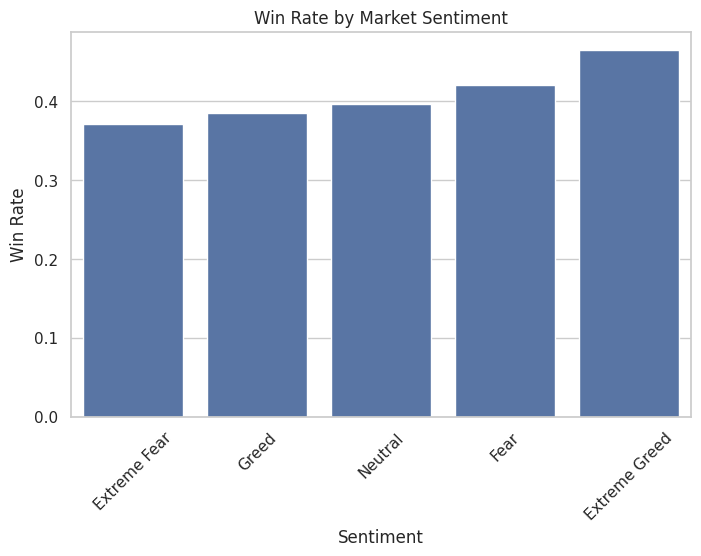

In [401]:
sns.barplot(
    x=win_rate_by_sentiment.index,
    y=win_rate_by_sentiment.values
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

##Loss-Day Probability by Market Sentiment (Drawdown Proxy)

To evaluate downside risk across sentiment regimes, we compute the proportion of days where aggregated daily PnL is negative. This serves as a drawdown proxy and highlights risk exposure under different market conditions.

In [402]:
# ============================================
# Loss-Day Probability by Market Sentiment (Drawdown Proxy)
# ============================================

# Step 1: Aggregate daily PnL per account
daily_pnl = (
    df.groupby(['Account', 'date', 'sentiment'])['Closed PnL']
    .sum()
    .reset_index()
)

# Step 2: Create loss-day indicator
daily_pnl['loss_day'] = daily_pnl['Closed PnL'] < 0

# Step 3: Compute loss probability by sentiment
loss_prob = (
    daily_pnl
    .groupby('sentiment')['loss_day']
    .mean()
    .reset_index()
)

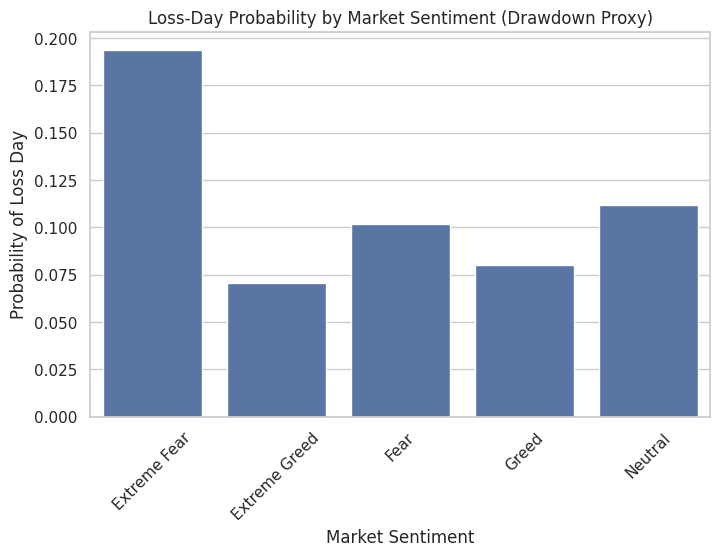

In [403]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=loss_prob,
    x='sentiment',
    y='loss_day'
)

plt.title('Loss-Day Probability by Market Sentiment (Drawdown Proxy)')
plt.ylabel('Probability of Loss Day')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.show()

### Column Standardization
To ensure consistency and readability throughout the analysis, we rename key columns using lowercase and standardized naming conventions.

In [404]:
# ============================================
# Standardize Column Names
# ============================================

df = df.rename(columns={
    'Account': 'account',
    'Closed PnL': 'closed_pnl',
    'Side': 'side',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Classification': 'sentiment'   # Ensure correct capitalization
})

# Verify updated column names
df.columns

Index(['account', 'Coin', 'Execution Price', 'size_tokens', 'size_usd', 'side',
       'Timestamp IST', 'Start Position', 'Direction', 'closed_pnl',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'time', 'date', 'sentiment', 'win'],
      dtype='object')

### Average Trade Size by Sentiment

To understand behavioral shifts across sentiment regimes, we analyze the average trade size (USD) under each market condition.

In [405]:
# Calculate average trade size by sentiment
avg_size_by_sentiment = (
    df.groupby('sentiment')['size_usd']
    .mean()
    .sort_values()
)

avg_size_by_sentiment

,size_usd
sentiment,
Extreme Greed,3112.251565
Neutral,4782.732661
Extreme Fear,5349.731843
Greed,5736.884375
Fear,7816.109931


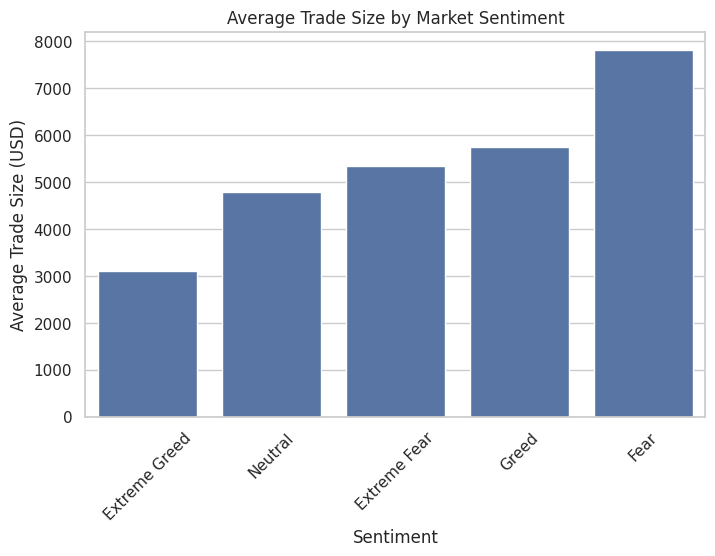

In [406]:
sns.barplot(
    x=avg_size_by_sentiment.index,
    y=avg_size_by_sentiment.values
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

### Average Daily Trade Activity by Sentiment

To control for differences in the number of days within each sentiment regime, we calculate the average number of trades executed per day under each market condition.

In [407]:
# Calculate average trades per day by sentiment
avg_trades_per_day = (
    df.groupby(['sentiment', 'date'])
    .size()
    .groupby('sentiment')
    .mean()
    .sort_values()
)

avg_trades_per_day

,0
sentiment,
Greed,260.637306
Extreme Greed,350.807018
Neutral,562.477612
Fear,679.527473
Extreme Fear,1528.571429


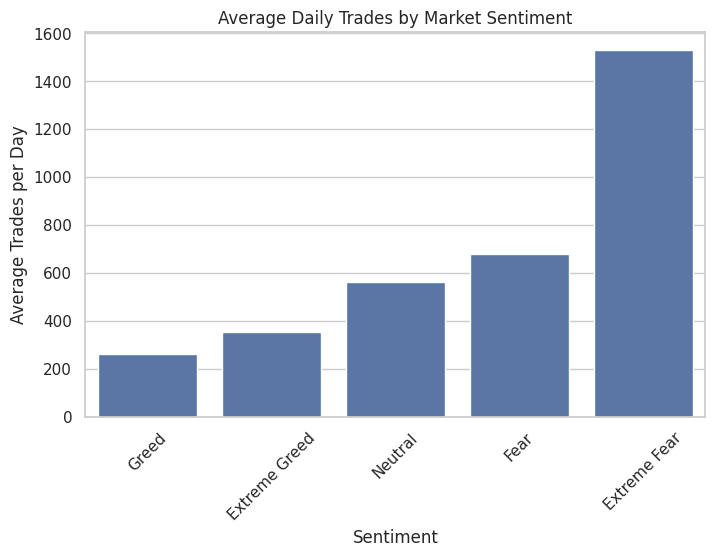

In [408]:
sns.barplot(
    x=avg_trades_per_day.index,
    y=avg_trades_per_day.values
)

plt.title("Average Daily Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trades per Day")
plt.xticks(rotation=45)
plt.show()

### Long / Short Position Bias by Sentiment

To understand directional positioning behavior, we examine the proportion of BUY and SELL trades under each sentiment regime.

In [409]:
# Calculate normalized long/short distribution by sentiment
position_bias = pd.crosstab(
    df['sentiment'],
    df['side'],
    normalize='index'
)

position_bias

side,BUY,SELL
sentiment,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


In [410]:
position_bias = position_bias.round(3)
position_bias

side,BUY,SELL
sentiment,,
Extreme Fear,0.511,0.489
Extreme Greed,0.449,0.551
Fear,0.490,0.510
Greed,0.489,0.511
Neutral,0.503,0.497


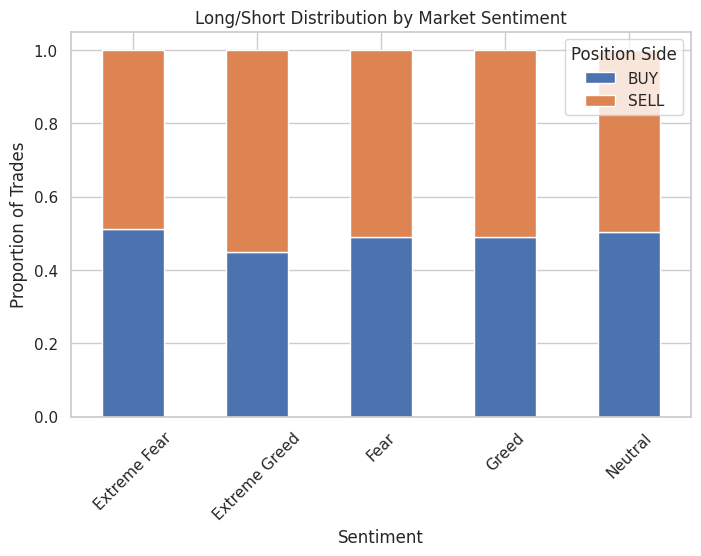

In [411]:
position_bias.plot(kind='bar', stacked=True)

plt.title("Long/Short Distribution by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Proportion of Trades")
plt.xticks(rotation=45)
plt.legend(title="Position Side")
plt.show()

### Segmentation Analysis: Frequent vs Infrequent Traders

Traders are segmented into **Frequent** and **Infrequent** groups based on the median number of trades executed per account.  
This median-based split ensures a balanced and data-driven classification of trading intensity while avoiding arbitrary thresholds.

In [412]:
# ============================================
# Frequency-Based Segmentation
# ============================================

# Step 1: Calculate total number of trades per trader
trade_counts = (
    df.groupby('account')
    .size()
    .reset_index(name='total_trades')
)

In [413]:
# Step 2: Determine median trade count
median_trades = trade_counts['total_trades'].median()

In [414]:
# Step 3: Assign traders to frequency segments
trade_counts['frequency_segment'] = np.where(
    trade_counts['total_trades'] > median_trades,
    'Frequent',
    'Infrequent'
)

In [415]:
# Step 4: Merge segment into main dataset
df = df.merge(
    trade_counts[['account', 'frequency_segment']],
    on='account',
    how='left'
)

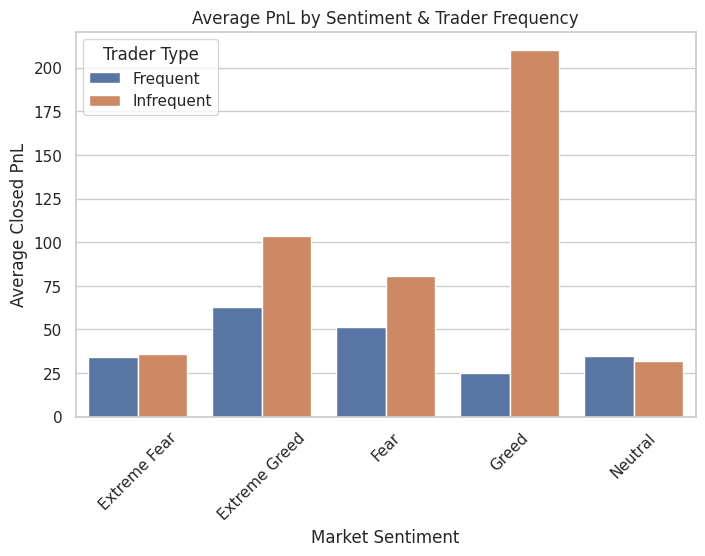

In [416]:
# ============================================
# Visualize Performance by Frequency Segment
# ============================================

segment_pnl = (
    df.groupby(['frequency_segment', 'sentiment'])['closed_pnl']
    .mean()
    .reset_index()
)

sns.barplot(
    data=segment_pnl,
    x='sentiment',
    y='closed_pnl',
    hue='frequency_segment'
)

plt.title("Average PnL by Sentiment & Trader Frequency")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.legend(title="Trader Type")
plt.show()

In [417]:
plt.tight_layout()

<Figure size 800x500 with 0 Axes>

### Downside Risk (Loss-Day Probability) by Sentiment & Trading Frequency



We evaluate whether trading intensity affects downside risk across different sentiment regimes.

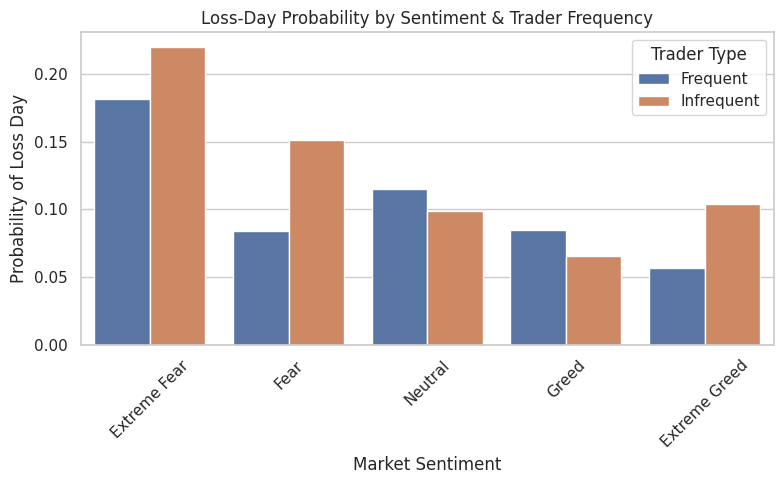

In [418]:
# Aggregate daily PnL with frequency segment
daily_pnl_freq = (
    df.groupby(['account','date','sentiment','frequency_segment'])['closed_pnl']
    .sum()
    .reset_index()
)

daily_pnl_freq['loss_day'] = daily_pnl_freq['closed_pnl'] < 0

loss_by_freq = (
    daily_pnl_freq.groupby(['frequency_segment','sentiment'])['loss_day']
    .mean()
    .reset_index()
)

# Define the order of sentiment categories for consistent plotting
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

sns.barplot(
    data=loss_by_freq,
    x='sentiment',
    y='loss_day',
    hue='frequency_segment',
    order=sentiment_order
)

plt.title("Loss-Day Probability by Sentiment & Trader Frequency")
plt.xlabel("Market Sentiment")
plt.ylabel("Probability of Loss Day")
plt.xticks(rotation=45)
plt.legend(title="Trader Type")
plt.tight_layout()
plt.show()

In [419]:
plt.tight_layout()

<Figure size 800x500 with 0 Axes>

### Average PnL by Frequency Segment and Sentiment

We compute the mean profitability for each trader frequency group across different market sentiment regimes.

In [420]:
# Calculate average PnL by frequency segment and sentiment
segment_pnl_summary = (
    df.groupby(['frequency_segment', 'sentiment'])['closed_pnl']
    .mean()
    .sort_index()
)

segment_pnl_summary

frequency_segment  sentiment    
Frequent           Extreme Fear      34.163353
                   Extreme Greed     62.870911
                   Fear              51.323784
                   Greed             25.004641
                   Neutral           34.579701
Infrequent         Extreme Fear      35.941979
                   Extreme Greed    103.264685
                   Fear              80.835791
                   Greed            210.210287
                   Neutral           31.845656
Name: closed_pnl, dtype: float64

## Segmentation: Consistent vs Inconsistent Traders

To evaluate performance stability, we calculate the standard deviation of PnL per trader as a proxy for volatility.  
Higher volatility indicates less consistent trading outcomes.

In [421]:
# ============================================
# Calculate Trader PnL Volatility
# ============================================

pnl_std = (
    df.groupby('account')['closed_pnl']
    .std()
    .reset_index(name='pnl_volatility')
)

# Preview volatility metric
pnl_std.head()

,account,pnl_volatility
0,0x083384f897ee0f19899168e3b1bec365f52a9012,4692.452329
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,134.073473
2,0x271b280974205ca63b716753467d5a371de622ab,542.182659
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,113.269353
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,255.829091


### Create Consistency Segments

Traders are segmented into **Consistent** and **Inconsistent** groups using the median PnL volatility as the threshold.  
This ensures a balanced and data-driven classification of performance stability.

In [422]:
# ============================================
# Create Consistency Segments
# ============================================

# Determine median volatility
median_volatility = pnl_std['pnl_volatility'].median()

# Assign traders to consistency segments
pnl_std['consistency_segment'] = np.where(
    pnl_std['pnl_volatility'] > median_volatility,
    'Inconsistent',
    'Consistent'
)

# Preview segmentation
pnl_std.head()

,account,pnl_volatility,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,4692.452329,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,134.073473,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,542.182659,Consistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,113.269353,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,255.829091,Consistent


### Loss-Day Probability by Consistency Segment and Sentiment

To assess downside risk differences between consistent and inconsistent traders, we compute the proportion of days with negative aggregated PnL under each sentiment regime.

In [423]:
df = df.merge(
    pnl_std[['account', 'consistency_segment']],
    on='account',
    how='left'
)

daily_pnl_cons = (
    df.groupby(['account','date','sentiment','consistency_segment'])['closed_pnl']
    .sum()
    .reset_index()
)

daily_pnl_cons['loss_day'] = daily_pnl_cons['closed_pnl'] < 0

In [424]:
loss_by_consistency = (
    daily_pnl_cons
    .groupby(['consistency_segment','sentiment'])['loss_day']
    .mean()
    .reset_index()
)

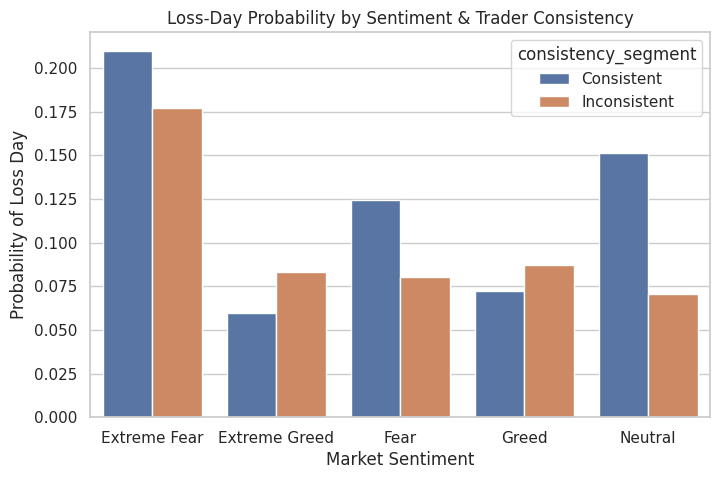

In [425]:
sns.barplot(
    data=loss_by_consistency,
    x='sentiment',
    y='loss_day',
    hue='consistency_segment'
)

plt.title('Loss-Day Probability by Sentiment & Trader Consistency')
plt.ylabel('Probability of Loss Day')
plt.xlabel('Market Sentiment')
plt.show()

In [426]:
# ============================================
# Consistency Segmentation
# ============================================

# Step 1: Calculate PnL volatility per trader
pnl_std = (
    df.groupby('account')['closed_pnl']
    .std()
    .reset_index(name='pnl_volatility')
)

In [427]:
# Step 2: Create consistency segment using median volatility
median_volatility = pnl_std['pnl_volatility'].median()

pnl_std['consistency_segment'] = np.where(
    pnl_std['pnl_volatility'] > median_volatility,
    'Inconsistent',
    'Consistent'
)

In [428]:
# Step 3: Merge into main dataset
df = df.merge(
    pnl_std[['account', 'consistency_segment']],
    on='account',
    how='left'
)

## Strategy Recommendations

Based on the analysis of trader performance and behavioral shifts across sentiment regimes, the following actionable insights are proposed:

### 1. Sentiment-Based Risk Scaling
During **Extreme Fear** regimes, downside risk (loss-day probability) increases significantly. Traders should reduce position sizing and avoid aggressive trading strategies under high-fear conditions.  
Conversely, during **Extreme Greed** regimes, profitability and win rates improve, suggesting controlled capital expansion may be justified.

### 2. Segment-Specific Capital Allocation
Infrequent traders demonstrate stronger performance during bullish sentiment regimes, indicating that lower turnover strategies benefit from trend persistence.  
High-volatility (inconsistent) traders amplify sentiment effects, generating higher gains during strong bullish phases but also increasing downside variability. Risk controls should be tightened for these traders during fear-driven markets.

These findings suggest that adaptive risk management and capital allocation strategies based on market sentiment and trader type can improve performance stability.